In [1]:
import os
import sys
import numpy as np
import cv2
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
# Fix PROJ paths BEFORE any imports
# Use rasterio's bundled proj data since that's what's failing
PROJ_PATH = '/home/ejalilva/.conda/envs/terratorch-tune/lib/python3.12/site-packages/rasterio/proj_data'
os.environ['PROJ_LIB'] = PROJ_PATH
os.environ['PROJ_DATA'] = PROJ_PATH

# Also try pyproj's path as a backup
PYPROJ_PATH = '/home/ejalilva/.conda/envs/terratorch-tune/lib/python3.12/site-packages/pyproj/proj_dir/share/proj'
os.environ['PYPROJ_DATADIR'] = PYPROJ_PATH

print(f"Set PROJ_LIB to: {os.environ['PROJ_LIB']}")
print(f"Set PYPROJ_DATADIR to: {os.environ['PYPROJ_DATADIR']}")

# Verify the file exists
proj_db = os.path.join(PROJ_PATH, 'proj.db')
if os.path.exists(proj_db):
    print(f"✓ proj.db found at: {proj_db}")
else:
    print(f"✗ proj.db NOT found at: {proj_db}")

# Clean up any conflicting GEOSpyD paths
if 'PATH' in os.environ:
    path_parts = os.environ['PATH'].split(':')
    clean_path = [p for p in path_parts if 'GEOSpyD' not in p]
    os.environ['PATH'] = ':'.join(clean_path)
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
os.environ['PROJ_NETWORK'] = 'OFF'  # Disable PROJ network access
import pyproj
pyproj.network.set_network_enabled(False)

Set PROJ_LIB to: /home/ejalilva/.conda/envs/terratorch-tune/lib/python3.12/site-packages/rasterio/proj_data
Set PYPROJ_DATADIR to: /home/ejalilva/.conda/envs/terratorch-tune/lib/python3.12/site-packages/pyproj/proj_dir/share/proj
✓ proj.db found at: /home/ejalilva/.conda/envs/terratorch-tune/lib/python3.12/site-packages/rasterio/proj_data/proj.db


In [3]:
# Get absolute path of the local package
local_package_path = os.path.abspath(os.path.join(os.getcwd(), '../..', 'terratorch'))

# Add the path to system path if it's not already there
if local_package_path not in sys.path:
    sys.path.insert(0, local_package_path)

# If you had previously imported terratorch, you'll need to reload it
import importlib
if 'terratorch' in sys.modules:
    importlib.reload(sys.modules['terratorch'])

import terratorch

# Verify the import
print(f"terratorch package location: {terratorch.__file__}")

ERROR:albumentations.check_version:Error fetching version info
Traceback (most recent call last):
  File "/home/ejalilva/.conda/envs/terratorch-tune/lib/python3.12/urllib/request.py", line 1344, in do_open
    h.request(req.get_method(), req.selector, req.data, headers,
  File "/home/ejalilva/.conda/envs/terratorch-tune/lib/python3.12/http/client.py", line 1338, in request
    self._send_request(method, url, body, headers, encode_chunked)
  File "/home/ejalilva/.conda/envs/terratorch-tune/lib/python3.12/http/client.py", line 1384, in _send_request
    self.endheaders(body, encode_chunked=encode_chunked)
  File "/home/ejalilva/.conda/envs/terratorch-tune/lib/python3.12/http/client.py", line 1333, in endheaders
    self._send_output(message_body, encode_chunked=encode_chunked)
  File "/home/ejalilva/.conda/envs/terratorch-tune/lib/python3.12/http/client.py", line 1093, in _send_output
    self.send(msg)
  File "/home/ejalilva/.conda/envs/terratorch-tune/lib/python3.12/http/client.py", li

terratorch package location: /gpfsm/dnb33/ejalilva/dev/terratorch/terratorch/__init__.py


In [4]:
from terratorch.datamodules import MultiTemporalCropClassificationDataModule
from terratorch.datasets import MultiTemporalCropClassification
from terratorch.tasks import SemanticSegmentationTask
from terratorch.datasets.transforms import FlattenTemporalIntoChannels, UnflattenTemporalFromChannels


In [5]:
import albumentations as A
from albumentations import Compose, Flip
from albumentations.pytorch import ToTensorV2

In [6]:
import lightning.pytorch as pl
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint

In [7]:
# Import our custom files
from confusionMatrix_callback import ConfusionMatrixCallback
from extended_semantic_segmentation_task import ExtendedSemanticSegmentationTask

In [8]:
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print("Number of GPUs:", num_gpus)

Number of GPUs: 2


In [9]:
# ! tar -xvzf ../../data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/training_chips.tgz -C ../../data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/ && \
# tar -xvzf ../../data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/validation_chips.tgz -C ../../data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/ && \
# mv ../../data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/training_data.txt ../../data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/training_chips/ && \
# mv ../../data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/validation_data.txt ../../data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/validation_chips/


In [10]:
DATASET_PATH = '/discover/nobackup/ejalilva/data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-irrigation-classificaction-openet/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/'
base_weights = [29.7, 2.1, 3.2, 5.5] # Use sqrt for softer weighting

In [11]:
# those are the recommended transforms for this task
transforms = [
    terratorch.datasets.transforms.FlattenTemporalIntoChannels(),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    # A.RandomBrightnessContrast(p=0.5),
    # A.Normalize(),
    ToTensorV2(),
    terratorch.datasets.transforms.UnflattenTemporalFromChannels(n_timesteps=3),
]

In [12]:
# this datamodule allows access to the dataset in its various splits.
datamodule = MultiTemporalCropClassificationDataModule(
    batch_size=16, # 16 images at a time
    data_root=DATASET_PATH,
    train_transform=transforms, # transformation to apply to the data during training
    val_transform=transforms, # transformation to apply to the data during validation
    test_transform=transforms, # transformation to apply to the data during test
    expand_temporal_dimension=True,
)

In [13]:
# Setup datamodule to get class information
datamodule.setup("fit")
train_dataset = datamodule.train_dataset

# Get class names for our confusion matrix
class_names = train_dataset.class_names

In [14]:
# # Create our confusion matrix callback
# confusion_matrix_callback = ConfusionMatrixCallback(
#     num_classes=4,  # water, irrigated, rainfed, natural
#     class_names=class_names,
#     compute_on_train=True  # Set to False if you only want validation/test matrices
# )

In [15]:
# checking for the dataset means and stds
datamodule.means, datamodule.stds

([494.905781, 815.239594, 924.335066, 2968.881459, 2634.621962, 1739.579917],
 [284.925432, 357.84876, 575.566823, 896.601013, 951.900334, 921.407808])

In [16]:
# checking datasets train split size
datamodule.setup("fit")
train_dataset = datamodule.train_dataset
len(train_dataset)

2013

In [17]:
# checking datasets available bands
train_dataset.all_band_names

('BLUE', 'GREEN', 'RED', 'NIR_NARROW', 'SWIR_1', 'SWIR_2')

In [18]:
# checking datasets classes
train_dataset.class_names

('Water', 'non-Ag', 'Irrigated', 'Rainfed')

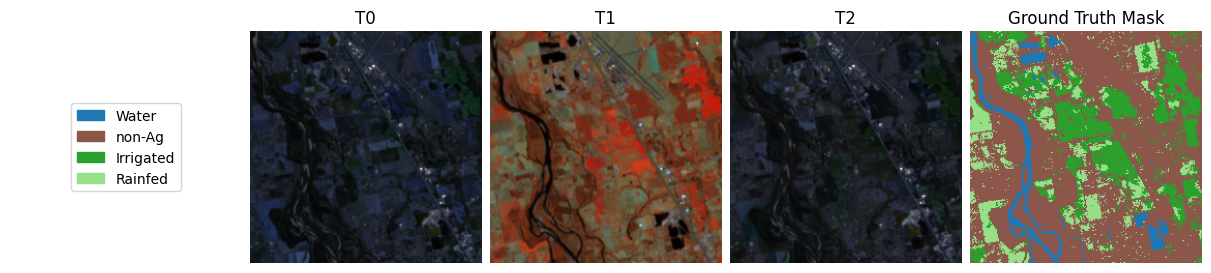

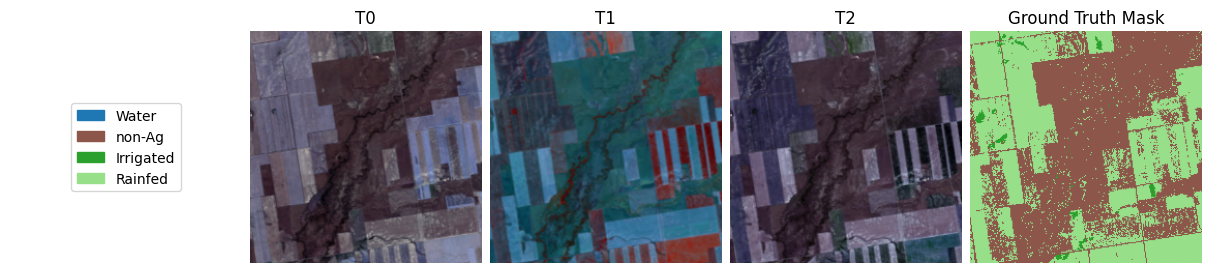

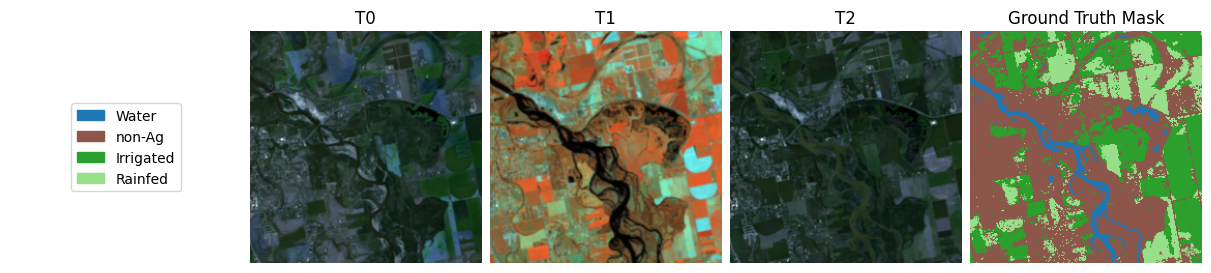

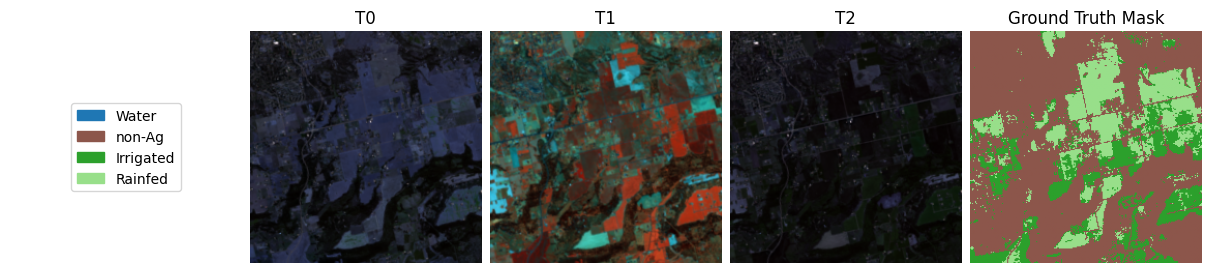

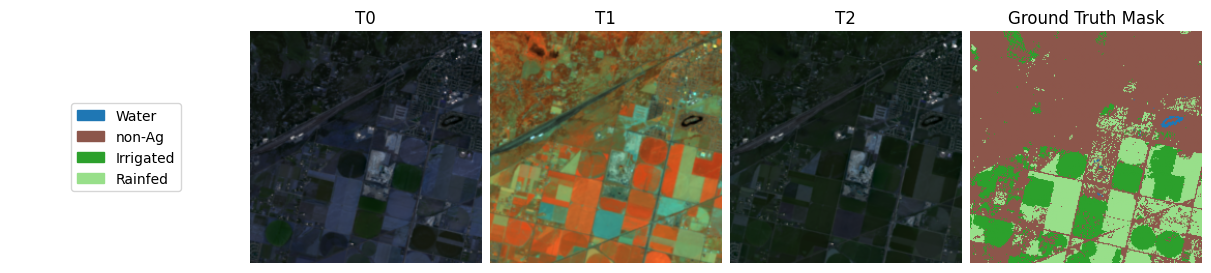

In [19]:
# ploting a few samples
for i in range(20,25):
    train_dataset.plot(train_dataset[i])

In [20]:
# checking datasets validation split size
val_dataset = datamodule.val_dataset
len(val_dataset)

486

In [21]:
# checking datasets testing split size
datamodule.setup("test")
test_dataset = datamodule.test_dataset
len(test_dataset)

486

In [22]:
pl.seed_everything(0)

# Logger
logger = TensorBoardLogger(
    save_dir="output",
    name="tutorial"
)

# colab will kill the kernel after ~24 epochs, therefore stopping after two and pull the correct checkpoint after
max_epochs = 1 if 'google.colab' in sys.modules else 2

checkpoint_callback = ModelCheckpoint(
    dirpath="checkpoints/",                 # Directory to save the checkpoints
    mode="max",                             # Maximize variable
    monitor="val/Multiclass_Jaccard_Index", # Variable to monitor
    filename="hyper-{epoch:02d}",           # Filename format
    save_top_k=-1,                          # Save all checkpoints
    every_n_epochs=50,                      # Save every epoch
    save_on_train_epoch_end=True            # Ensure saving after each epoch
)

# Trainer
trainer = pl.Trainer(
    accelerator="auto",
    strategy="auto",
    devices="auto",
    num_nodes=1,
    logger = logger,
    max_epochs=max_epochs,
    check_val_every_n_epoch=2,
    log_every_n_steps=10,
    enable_checkpointing=True,
    # callbacks=[checkpoint_callback, confusion_matrix_callback],  # Added our callback here
    callbacks=checkpoint_callback,  # Added our callback here
    default_root_dir="root_dir",
)

# DataModule
data_module = MultiTemporalCropClassificationDataModule(
    batch_size=16, # changed from 8 to 16
    data_root=DATASET_PATH,
    train_transform=transforms,
    val_transform=transforms,
    test_transform=transforms,
    reduce_zero_label=False,
    expand_temporal_dimension=True,
    use_metadata=True, # Multicropclassification dataset has metadata for location and time
)

INFO: [rank: 0] Seed set to 0
INFO:lightning.fabric.utilities.seed:[rank: 0] Seed set to 0
INFO: Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
INFO:lightning.pytorch.utilities.rank_zero:Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs


In [ ]:
import optuna

# Load study
study = optuna.load_study(
    study_name="prithvi_tuning_V4",
    storage="sqlite:///optuna_study_prithvi_tuning_V4.db"
)
BEST = study.best_params
BEST['freeze_backbone'] = False
BEST['use_scheduler'] = False
BEST['use_class_weights'] = True
BEST['class_weights'] = 1 # all class weight scale 
BEST['batch_size'] = 8
BEST['decoder_channels'] = 256
BEST['optimizer'] = 'AdamW'
# Helper to get neck indices based on backbone
def get_neck_indices(backbone):
    if 'v2_600' in backbone:
        return [7, 15, 23, 31]
    return [5, 11, 17, 23]

# Model with dynamically loaded params
model = SemanticSegmentationTask(
    model_args={
        "decoder": "UperNetDecoder",
        "backbone_pretrained": True,
        "backbone": "prithvi_eo_v2_300_tl",
        "backbone_in_channels": 6,
        "backbone_features_only": True,
        "rescale": True,
        "backbone_bands": ["BLUE", "GREEN", "RED", "NIR_NARROW", "SWIR_1", "SWIR_2"],
        "backbone_num_frames": 3,
        "num_classes": 4,
        "head_dropout": BEST['head_dropout'],
        "decoder_channels": BEST['decoder_channels'],
        "decoder_scale_modules": True,
        "necks": [
            {
                "name": "SelectIndices",
                "indices": get_neck_indices(BEST['backbone'])
            },
            {
                "name": "ReshapeTokensToImage",
                "effective_time_dim": 3
            }
        ]
    },
    plot_on_val=False,
    class_weights = [np.sqrt(w) * BEST['class_weights'] for w in base_weights] if BEST['use_class_weights'] else None,
    loss="ce",
    lr=BEST['lr'],
    optimizer=BEST['optimizer'],
    optimizer_hparams={"weight_decay": BEST['weight_decay']},
    ignore_index=-1,
    freeze_backbone=BEST['freeze_backbone'],
    freeze_decoder=False,
    model_factory="EncoderDecoderFactory",
)

In [ ]:
# # Model
# model = ExtendedSemanticSegmentationTask(
#     model_args={
#         "decoder": "UperNetDecoder",
#         "backbone_pretrained": True,
#         "backbone": "prithvi_eo_v2_300_tl", # Model can be either prithvi_eo_v2_300, prithvi_eo_v2_300_tl, prithvi_eo_v2_600, prithvi_eo_v2_600_tl
#         "backbone_in_channels": 6,
#         "backbone_features_only": True,
#         # "backbone_coords_encoding": ["time", "location"], # this must be used to use time and location metadata
#         "rescale": True,
#         "backbone_bands": ["BLUE", "GREEN", "RED", "NIR_NARROW", "SWIR_1", "SWIR_2"],
#         "backbone_num_frames": 3,
#         "num_classes": 4,
#         "head_dropout": 0.3, # increased from 0.1 to 0.3
#         "decoder_channels": 256,
#         "decoder_scale_modules": True,
#         "necks": [
#             {
#                 "name": "SelectIndices",
#                 #"indices": [2, 5, 8, 11] # indices for prithvi_vit_100
#                 "indices": [5, 11, 17, 23] # indices for prithvi_eo_v2_300
#                 # "indices": [7, 15, 23, 31] # indices for prithvi_eo_v2_600
#             },
#             {
#                 "name": "ReshapeTokensToImage",
#                 "effective_time_dim": 3
#             }
#         ]

#     },
#     plot_on_val=False,
#     class_weights=[42.59142538,  9.41862502,  3.79541504,  1.64779206], # water, irrigated, rainfed, natural
#     loss="ce",
#     lr=1.0e-4,
#     optimizer="AdamW",
#     optimizer_hparams={"weight_decay": 0.3},
#     ignore_index=-1,
#     freeze_backbone=False,
#     freeze_decoder=False,
#     model_factory="EncoderDecoderFactory",
# )

In [ ]:
# Training
trainer.fit(model, datamodule=data_module)

In [26]:
trainer.test(model, datamodule=data_module, ckpt_path='best_model_training/checkpoints/best-epoch=19-val/Multiclass_Jaccard_Index=0.5796.ckpt')

# # Generate a final summary report with class-wise metrics
# print("\nClass-wise Performance Summary:")
# print("-------------------------------")
# for i, class_name in enumerate(class_names):
#     print(f"Class {i} ({class_name}):")
#     print(f"  IoU: {model.test_outputs[-1]['Multiclass_IoU'][i].item():.4f}")
#     print(f"  F1: {model.test_outputs[-1]['Multiclass_F1'][i].item():.4f}")
#     print(f"  Precision: {model.test_outputs[-1]['Multiclass_Precision'][i].item():.4f}")
#     print(f"  Recall: {model.test_outputs[-1]['Multiclass_Recall'][i].item():.4f}")
#     print("-------------------------------")

# now we can use the model for predictions and ploting!
best_ckpt_path = 'best_model_training/checkpoints/best-epoch=59-val/Multiclass_Jaccard_Index=0.6082.ckpt'
model = SemanticSegmentationTask.load_from_checkpoint(
    best_ckpt_path,
    model_args=model.hparams.model_args,
    model_factory=model.hparams.model_factory
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_loader = data_module.test_dataloader()
model.to(device)
with torch.no_grad():
    batch = next(iter(test_loader))
    images = batch["image"].to(device)
    masks = batch["mask"].numpy()
    other_keys = batch.keys() - {"image", "mask", "filename"}
    rest = {k: batch[k].to(device) for k in other_keys}

    outputs = model(images, **rest)
    preds = torch.argmax(outputs.output, dim=1).cpu().numpy()

for i in range(10,15):
    sample = {key: batch[key][i] for key in batch}
    sample["prediction"] = preds[i]
    test_dataset.plot(sample)

In [29]:
print(test_dataset.class_names)


('Water', 'non-Ag', 'Irrigated', 'Rainfed')


In [30]:
for i in range(10):
    mask = batch["mask"][i].numpy()
    unique_classes = np.unique(mask)
    print(f"Sample {i}: classes present = {unique_classes}")

Sample 0: classes present = [0 1 2 3]
Sample 1: classes present = [0 1 2 3]
Sample 2: classes present = [0 1 2 3]
Sample 3: classes present = [0 1 2 3]
Sample 4: classes present = [0 1 2 3]
Sample 5: classes present = [0 1 2 3]
Sample 6: classes present = [0 1 2 3]
Sample 7: classes present = [0 1 2 3]
Sample 8: classes present = [0 1 2 3]
Sample 9: classes present = [0 1 2 3]


In [15]:
#!/usr/bin/env python
"""Train model with V5 Trial 30 params + class weights."""

import os
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'
os.environ['PROJ_LIB'] = '/home/ejalilva/.conda/envs/terratorch-tune/lib/python3.12/site-packages/rasterio/proj_data'
os.environ['PROJ_DATA'] = os.environ['PROJ_LIB']
os.environ['HF_DATASETS_OFFLINE'] = '1'
os.environ['PROJ_NETWORK'] = 'OFF'
import pyproj
pyproj.network.set_network_enabled(False)

import sys
import torch
import json
import numpy as np
torch.set_float32_matmul_precision('medium')

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..', 'terratorch')))

import terratorch
from terratorch.datamodules import MultiTemporalCropClassificationDataModule
from terratorch.tasks import SemanticSegmentationTask
import albumentations as A
from albumentations.pytorch import ToTensorV2
import lightning.pytorch as pl
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from loss_callback import LossTrackerCallback
from confusionMatrix_callback_withVal import ConfusionMatrixCallback

# ============== LOAD Best trial V7 ==============
# import optuna
# study = optuna.load_study(
#     study_name="prithvi_tuning_V7",
#     storage="sqlite:///optuna_study_prithvi_tuning_V7.db"
# )
# BEST_PARAMS = study.best_params

import optuna
study = optuna.load_study(
    study_name="prithvi_tuning_V7",
    storage="sqlite:///optuna_study_prithvi_tuning_V7.db"
)
trail03 = study.trials[3]
print(f"Loaded trial 03: Jaccard={trail03.value:.4f}")
print(f"Params: {trail03.params}")
BEST_PARAMS = trail03.params

# ============== CONFIG ==============
DATASET_PATH = '/discover/nobackup/ejalilva/data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-irrigation-classificaction-openet/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/'
base_weights = [29.7, 2.1, 3.2, 5.5]
OUTPUT_DIR = 'best_model_V7_final'
MAX_EPOCHS = 120

# From best params
backbone_model = BEST_PARAMS['backbone']
batch_size = BEST_PARAMS['batch_size']
decoder_channels = BEST_PARAMS['decoder_channels']
lr = BEST_PARAMS['lr']
weight_decay = BEST_PARAMS['weight_decay']
head_dropout = BEST_PARAMS['head_dropout']
optimizer_type = BEST_PARAMS['optimizer']

# Neck indices - dynamic based on backbone
neck_indices = [7, 15, 23, 31] if 'v2_600' in backbone_model else [5, 11, 17, 23]

# Class weights - log-scaled
class_weights = [np.log1p(w) for w in base_weights]

print(f"\nConfig:")
print(f"  backbone: {backbone_model}")
print(f"  batch_size: {batch_size}")
print(f"  decoder_channels: {decoder_channels}")
print(f"  lr: {lr:.6f}")
print(f"  weight_decay: {weight_decay:.4f}")
print(f"  head_dropout: {head_dropout:.4f}")
print(f"  class_weights: {[f'{w:.2f}' for w in class_weights]}")

# ============== SETUP ==============
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print(f"Number of GPUs: {num_gpus}")

pl.seed_everything(42)
os.makedirs(OUTPUT_DIR, exist_ok=True)

transforms = [
    terratorch.datasets.transforms.FlattenTemporalIntoChannels(),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    ToTensorV2(),
    terratorch.datasets.transforms.UnflattenTemporalFromChannels(n_timesteps=3),
]

data_module = MultiTemporalCropClassificationDataModule(
    batch_size=batch_size,
    data_root=DATASET_PATH,
    train_transform=transforms,
    val_transform=transforms,
    test_transform=transforms,
    reduce_zero_label=False,
    expand_temporal_dimension=True,
    use_metadata=True,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True,
)

neck_indices = [7, 15, 23, 31] if 'v2_600' in backbone_model else [5, 11, 17, 23]

model = SemanticSegmentationTask(
    model_args={
        "decoder": "UperNetDecoder",
        "backbone_pretrained": True,
        "backbone": backbone_model,
        "backbone_in_channels": 6,
        "backbone_features_only": True,
        "backbone_coords_encoding": ["time", "location"],
        "rescale": True,
        "backbone_bands": ["BLUE", "GREEN", "RED", "NIR_NARROW", "SWIR_1", "SWIR_2"],
        "backbone_num_frames": 3,
        "num_classes": 4,
        "head_dropout": head_dropout,
        "decoder_channels": decoder_channels,
        "decoder_scale_modules": True,
        "necks": [
            {"name": "SelectIndices", "indices": neck_indices},
            {"name": "ReshapeTokensToImage", "effective_time_dim": 3}
        ]
    },
    plot_on_val=False,
    class_weights=class_weights,
    loss="ce",
    lr=lr,
    optimizer=optimizer_type,
    optimizer_hparams={"weight_decay": weight_decay},
    ignore_index=-1,
    freeze_backbone=False,
    freeze_decoder=False,
    model_factory="EncoderDecoderFactory",
)

callbacks = [
    ModelCheckpoint(
        dirpath=os.path.join(OUTPUT_DIR, "checkpoints"),
        monitor="val/Multiclass_Jaccard_Index",
        mode="max",
        filename="best-{epoch:02d}-{val/Multiclass_Jaccard_Index:.4f}",
        save_top_k=3,
        save_last=True
    ),
    EarlyStopping(
        monitor="val/Multiclass_Jaccard_Index",
        mode="max",
        patience=15,
        min_delta=0.001
    ),
    LossTrackerCallback(),
    ConfusionMatrixCallback(
        class_names=["Water", "Natural", "Irrigated", "Rainfed"],
        save_dir=os.path.join(OUTPUT_DIR, "confusion_matrices")
    ),
]

trainer = pl.Trainer(
    accelerator="auto",
    devices=num_gpus,
    precision="bf16-mixed",
    logger=TensorBoardLogger(save_dir=OUTPUT_DIR, name="logs"),
    max_epochs=MAX_EPOCHS,
    check_val_every_n_epoch=2,
    log_every_n_steps=10,
    callbacks=callbacks,
    default_root_dir=OUTPUT_DIR,
    strategy='ddp_find_unused_parameters_true' if num_gpus > 1 else 'auto'
)

# # ============== TRAIN ==============
# trainer.fit(model, datamodule=data_module)

# # ============== TEST ==============
# print("\nRunning test evaluation...")
# test_results = trainer.test(model, datamodule=data_module, ckpt_path='best')

# # Save results
# with open(os.path.join(OUTPUT_DIR, "results.json"), "w") as f:
#     json.dump({
#         "best_params": BEST_PARAMS,
#         "class_weights": class_weights,
#         "test_results": test_results,
#         "best_checkpoint": trainer.checkpoint_callback.best_model_path
#     }, f, indent=2)

# print(f"\nDone! Results saved to {OUTPUT_DIR}/")

INFO: [rank: 0] Seed set to 42
INFO:lightning.fabric.utilities.seed:[rank: 0] Seed set to 42


Loaded trial 03: Jaccard=0.5875
Params: {'backbone': 'prithvi_eo_v2_300_tl', 'batch_size': 32, 'decoder_channels': 256, 'lr': 5.484108603764764e-05, 'weight_decay': 0.0848876216140871, 'head_dropout': 0.17394178221021084, 'optimizer': 'AdamW'}

Config:
  backbone: prithvi_eo_v2_300_tl
  batch_size: 32
  decoder_channels: 256
  lr: 0.000055
  weight_decay: 0.0849
  head_dropout: 0.1739
  class_weights: ['3.42', '1.13', '1.44', '1.87']
Number of GPUs: 1


INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (('ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL', 'Prithvi_EO_V2_300M_TL.pt'))
INFO:root:Loaded weights for HLSBands.BLUE in position 0 of patch embed
INFO:root:Loaded weights for HLSBands.GREEN in position 1 of patch embed
INFO:root:Loaded weights for HLSBands.RED in position 2 of patch embed
INFO:root:Loaded weights for HLSBands.NIR_NARROW in position 3 of patch embed
INFO:root:Loaded weights for HLSBands.SWIR_1 in position 4 of patch embed
INFO:root:Loaded weights for HLSBands.SWIR_2 in position 5 of patch embed
INFO: Using bfloat16 Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:

INFO: Restoring states from the checkpoint path at ./best_model_V7_final/checkpoints/best-epoch=111-val/Multiclass_Jaccard_Index=0.6195.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at ./best_model_V7_final/checkpoints/best-epoch=111-val/Multiclass_Jaccard_Index=0.6195.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: Loaded model weights from the checkpoint at ./best_model_V7_final/checkpoints/best-epoch=111-val/Multiclass_Jaccard_Index=0.6195.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Loaded model weights from the checkpoint at ./best_model_V7_final/checkpoints/best-epoch=111-val/Multiclass_Jaccard_Index=0.6195.ckpt
INFO: SLURM auto-requeueing enabled. Setting signal handlers.
INFO:lightning.pytorch.trainer.connectors.signal_connector:SLURM auto-requeueing enabled. Setting signal handlers.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃             Test metric             ┃            DataLoader 0             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test/Multiclass_Accuracy       │         0.7788571715354919          │
│      test/Multiclass_F1_Score       │         0.7788571715354919          │
│    test/Multiclass_Jaccard_Index    │         0.6072287559509277          │
│ test/Multiclass_Jaccard_Index_Micro │         0.6378101110458374          │
│              test/loss              │         0.6558614373207092          │
│      test/multiclassaccuracy_0      │         0.7458090782165527          │
│      test/multiclassaccuracy_1      │         0.8490256667137146          │
│      test/multiclassaccuracy_2      │         0.7580022811889648          │
│      test/multiclassaccuracy_3      │         0.6397089958190918          │
│    test/multiclassjaccardindex_0    │          0.611865758895874          │
│    test/multiclassjaccardindex_1    │         0.7335366010665894          │
│    test/multiclassjaccardindex_2    │         0.6126164793968201          │
│    test/multiclassjaccardindex_3    │         0.4708963632583618          │
└─────────────────────────────────────┴─────────────────────────────────────┘

INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (('ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL', 'Prithvi_EO_V2_300M_TL.pt'))
INFO:root:Loaded weights for HLSBands.BLUE in position 0 of patch embed
INFO:root:Loaded weights for HLSBands.GREEN in position 1 of patch embed
INFO:root:Loaded weights for HLSBands.RED in position 2 of patch embed
INFO:root:Loaded weights for HLSBands.NIR_NARROW in position 3 of patch embed
INFO:root:Loaded weights for HLSBands.SWIR_1 in position 4 of patch embed
INFO:root:Loaded weights for HLSBands.SWIR_2 in position 5 of patch embed
/gpfsm/dnb33/ejalilva/dev/terratorch/terratorch/models/decoders/upernet_decoder.py:37: UserWarning: DeprecationWarning: scale_modules is deprecated and will be removed in future versions. Use LearnedInterpolateToPyramidal neck instead.
  warnings.warn(


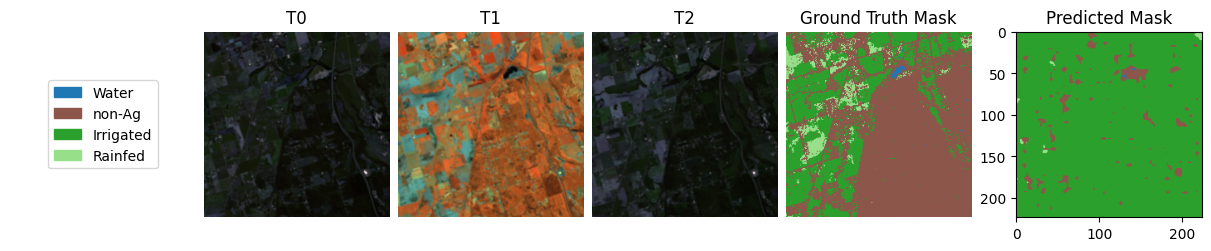

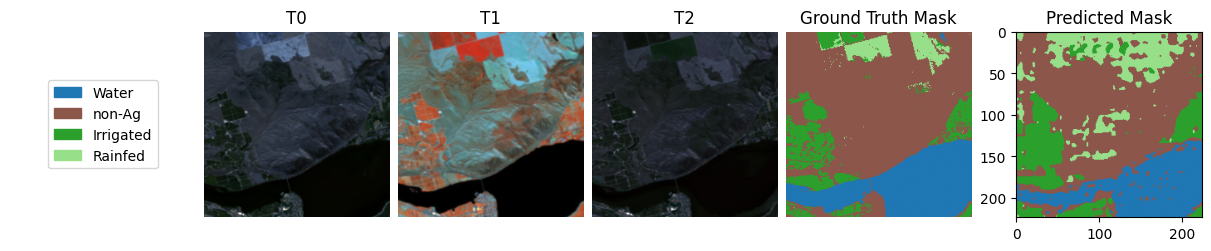

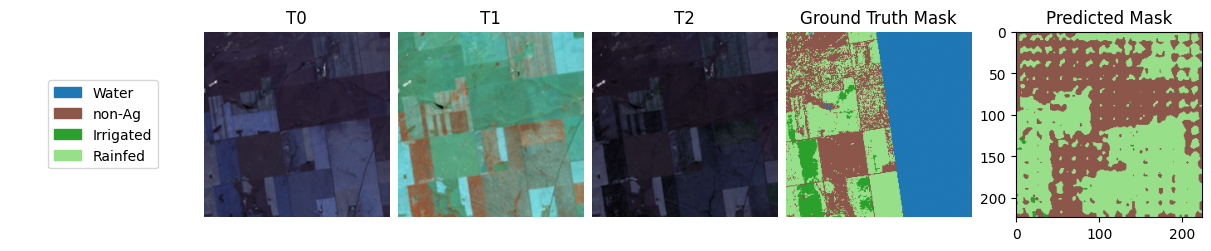

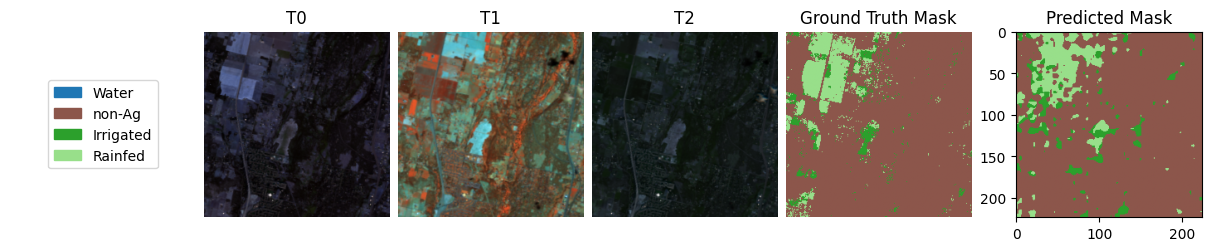

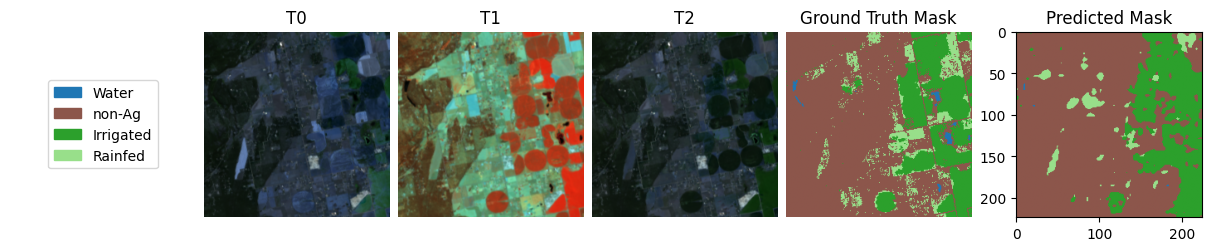

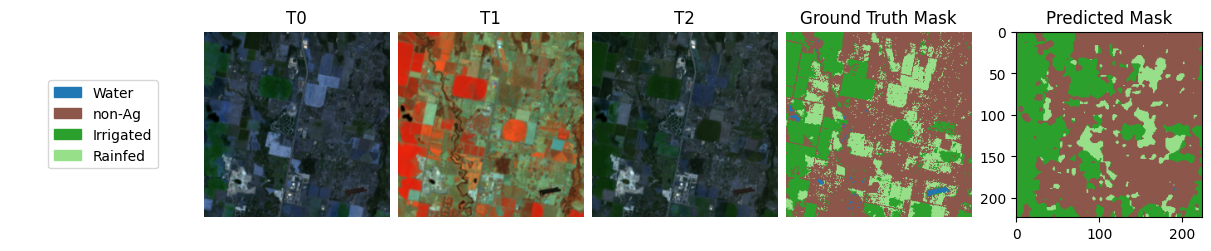

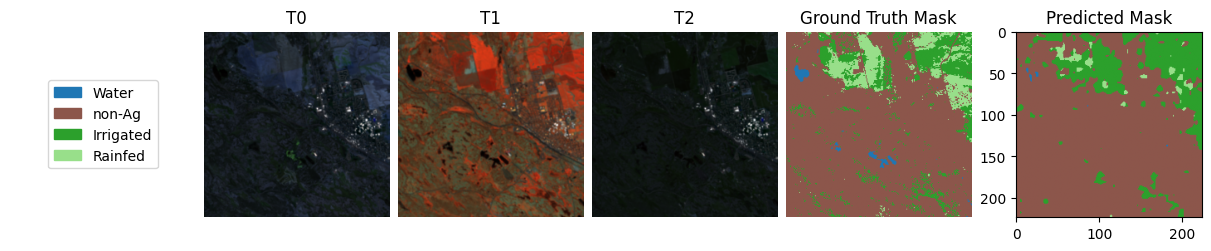

In [17]:
trainer.test(model, datamodule=data_module, ckpt_path='./best_model_V7_final/checkpoints/best-epoch=111-val/Multiclass_Jaccard_Index=0.6195.ckpt')

# # Generate a final summary report with class-wise metrics
# print("\nClass-wise Performance Summary:")
# print("-------------------------------")
# for i, class_name in enumerate(class_names):
#     print(f"Class {i} ({class_name}):")
#     print(f"  IoU: {model.test_outputs[-1]['Multiclass_IoU'][i].item():.4f}")
#     print(f"  F1: {model.test_outputs[-1]['Multiclass_F1'][i].item():.4f}")
#     print(f"  Precision: {model.test_outputs[-1]['Multiclass_Precision'][i].item():.4f}")
#     print(f"  Recall: {model.test_outputs[-1]['Multiclass_Recall'][i].item():.4f}")
#     print("-------------------------------")

# checking datasets testing split size
data_module.setup("test")
test_dataset = data_module.test_dataset
len(test_dataset)

# now we can use the model for predictions and ploting!
best_ckpt_path = './best_model_V7_final/checkpoints/best-epoch=111-val/Multiclass_Jaccard_Index=0.6195.ckpt'
model = SemanticSegmentationTask.load_from_checkpoint(
    best_ckpt_path,
    model_args=model.hparams.model_args,
    model_factory=model.hparams.model_factory
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_loader = data_module.test_dataloader()
model.to(device)
with torch.no_grad():
    batch = next(iter(test_loader))
    images = batch["image"].to(device)
    masks = batch["mask"].numpy()
    other_keys = batch.keys() - {"image", "mask", "filename"}
    rest = {k: batch[k].to(device) for k in other_keys}

    outputs = model(images, **rest)
    preds = torch.argmax(outputs.output, dim=1).cpu().numpy()

for i in range(1,8):
    sample = {key: batch[key][i] for key in batch}
    sample["prediction"] = preds[i]
    test_dataset.plot(sample)